In [1]:
# Imports.
import numpy as np;
import xarray as xr;
import matplotlib.pyplot as plt;
import h5_reader_xr as reader;
import phi2D_utilities as utils;

# Styling.
plt.style.use("ggplot");

In [3]:
# Test inputs - delete when done!
directory_path = "/zhisongqu_data/seth/GYSELA/raw/fresh_batch_8.0/DN_RECTEST_CULHAM_NVPAR255";
delta_t = reader.fetch_delta_t(directory_path);
data_arrays = reader.fetch_phi2D_data(directory_path);

<>:32: SyntaxWarning: invalid escape sequence '\p'
<>:32: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_2388146/485442342.py:32: SyntaxWarning: invalid escape sequence '\p'
  plot_rosenbluth_hinton(data_arrays, delta_t, dt_diag = 50, effective_radius = 0.7, title_suffix = "$Nv_\parallel = 256$", signal_band_pass = True);


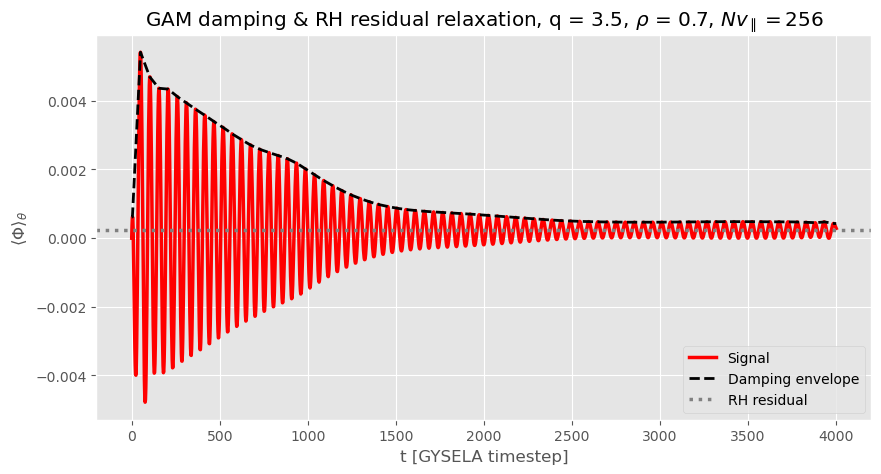

In [4]:
def plot_rosenbluth_hinton(phi2D_list, delta_t, dt_diag, title_suffix = "", effective_radius = 0.7, residual_window = 100, signal_band_pass = True):
	
	# Signal isolation and data processing.
	radial_time_series = utils.generate_poloidally_averaged_time_series(phi2D_list, effective_radius);

	if signal_band_pass:
		radial_time_series = utils.butterworth_band_pass_filter(radial_time_series, dt_diag);

	# We recover the actual number of simulation time-steps here.
	# This does not actually change the size of the array, only its spacing.
	time_range = utils.generate_time_range_by_series(radial_time_series, delta_t, dt_diag);
	GAM_frequency = utils.extract_gam_frequency(phi2D_list, dt_diag, effective_radius);
	amplitude_envelope = utils.generate_damping_envelope(radial_time_series, GAM_frequency, dt_diag);
	residual_level = utils.calculate_residual_level(amplitude_envelope, residual_window);

	if signal_band_pass:
		# Restore residual levels as the band-pass eliminates this information.
		radial_time_series += residual_level;
		amplitude_envelope += residual_level;

	# Figure plotting logic.
	plt.figure(figsize = (10, 5));
	plt.plot(time_range, radial_time_series, color = "red", lw = 2.5, label = "Signal");
	plt.plot(time_range, amplitude_envelope, color = "black", linestyle = "--", label= "Damping envelope", lw = 2.0);
	plt.axhline(y = residual_level, color = "gray", linestyle = ":", label = f"RH residual", lw = 2.5);
	plt.xlabel("t [GYSELA timestep]");
	plt.ylabel(r"$\langle \Phi \rangle_\theta$");
	plt.title(f"GAM damping & RH residual relaxation, q = 3.5, $\\rho$ = {effective_radius}, {title_suffix}");
	plt.legend(frameon = True, loc = "lower right");
	plt.show();

plot_rosenbluth_hinton(data_arrays, delta_t, dt_diag = 50, effective_radius = 0.7, title_suffix = "$Nv_\parallel = 256$", signal_band_pass = True);